In [1]:
import sys
import pandas as pd

# 2. FIX PATH TO PROJECT ROOT
sys.path.append('../../')

In [3]:
poc = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/PoC/PoC_results.csv')
static = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/human_review_random_50.csv')
dynamic = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/RAG/dynamic_tagging_results.csv')

In [11]:
dynamic.head()

,number,text,label,reasoning,scientific_confidence,max_path_confidencence,consistency,shot1,shot2,shot3
0,INC0146510,Support - My YouSee/Web (PC/Mac)/Missing conte...,"(1g Self service, 2g Mit YouSee), 3 Web",The issue is within Mit YouSee on web where th...,0.9994,1.00,1.0,Support - My YouSee/Web (PC/Mac)/Missing conte...,Support - My YouSee/Web (PC/Mac)/Missing conte...,Support - My YouSee/Web (PC/Mac)/Missing conte...
1,INC0136096,Support - Dawn/With customer context/Customer ...,"(1 Misc incidents, 2 Other), 3 CPR issues in Dawn",The issue is about inability to update a custo...,0.9994,1.00,1.0,Support - Dawn/With customer context/Customer ...,Support - Dawn/With Customer context/Customer ...,Support - Dawn/With Customer context/Customer ...
2,INC0130177,Support - YouSee mail/Issue within webmail / u...,"(1g Self service, 2g Webmail), 3 Fraud",The issue concerns YouSee Webmail with suspect...,0.9628,0.90,1.0,Support - YouSee mail/Issue within webmail / u...,Support - YouSee mail/Issue within webmail / u...,Support - YouSee mail/Issue within webmail / u...
3,INC0122704,Support - My YouSee/App (Mobile/Tablet)/Missin...,"(1g Self service, 2g YS-play), 3 Missing right...",The issue is with YouSee Play access rights (e...,0.9922,0.99,1.0,Support - My YouSee/App (Mobile/Tablet)/Missin...,Support - My YouSee/App (Mobile/Tablet)/Missin...,Support - TV/Other/Rights The Customer logs in...
4,INC0131120,Order is not received at vendor Summary:\nIt l...,"(1 Misc incidents, 2 Other), 3 Quote error",The issue is a generic order/quote fallout whe...,0.9988,1.00,1.0,[FO seq: 26300] Order is not received at vendo...,[FO seq: 53000]Quote occupied by itself Summar...,Quote is not completed Summary: \nError messa...


In [15]:
# --- Normalize columns and merge all 3 datasets on 'number' ---
def _prepare_frame(df, name):
    required = ['number', 'label', 'reasoning']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

    text_col = 'text' if 'text' in df.columns else None
    conf_col = None
    for candidate in ['scientific_confidence', 'confidence_score']:
        if candidate in df.columns:
            conf_col = candidate
            break

    keep = ['number', 'label', 'reasoning']
    if text_col:
        keep.append(text_col)
    if conf_col:
        keep.append(conf_col)

    out = df[keep].copy()
    rename_map = {
        'label': f'label_{name}',
        'reasoning': f'reasoning_{name}',
    }
    if text_col:
        rename_map[text_col] = f'text_{name}'
    if conf_col:
        rename_map[conf_col] = f'scientific_confidence_{name}'

    return out.rename(columns=rename_map)

static_prepared = _prepare_frame(static, 'static')
dynamic_prepared = _prepare_frame(dynamic, 'dynamic')
poc_prepared = _prepare_frame(poc, 'poc')

merged = (
    static_prepared
    .merge(dynamic_prepared, on='number', how='inner')
    .merge(poc_prepared, on='number', how='inner')
)

# Keep one canonical text column
text_candidates = [c for c in ['text_poc', 'text_static', 'text_dynamic'] if c in merged.columns]
if text_candidates:
    merged['text'] = merged[text_candidates].bfill(axis=1).iloc[:, 0]

# Add max_path_confidence from static/dynamic if available
if 'max_path_confidence' in static.columns:
    merged = merged.merge(
        static[['number', 'max_path_confidence']].rename(
            columns={'max_path_confidence': 'max_path_confidence_static'}
        ),
        on='number',
        how='left',
    )
if 'max_path_confidencence' in dynamic.columns:
    merged = merged.merge(
        dynamic[['number', 'max_path_confidencence']].rename(
            columns={'max_path_confidencence': 'max_path_confidence_dynamic'}
        ),
        on='number',
        how='left',
    )

# Drop duplicate text columns and enforce requested order
drop_text_cols = [c for c in ['text_poc', 'text_static', 'text_dynamic'] if c in merged.columns]
if drop_text_cols:
    merged = merged.drop(columns=drop_text_cols)

ordered_cols = [
    'number',
    'text',
    'label_poc', 'label_static', 'label_dynamic',
    'reasoning_poc', 'reasoning_static', 'reasoning_dynamic',
    'scientific_confidence_poc', 'scientific_confidence_static', 'scientific_confidence_dynamic',
    'max_path_confidence_static', 'max_path_confidence_dynamic',
]

# Keep only columns that exist, then append any extras
ordered_existing = [c for c in ordered_cols if c in merged.columns]
remaining_cols = [c for c in merged.columns if c not in ordered_existing]
merged = merged[ordered_existing + remaining_cols]

print(f"Merged shape: {merged.shape}")
merged.head()

Merged shape: (50, 13)


,number,text,label_poc,label_static,label_dynamic,reasoning_poc,reasoning_static,reasoning_dynamic,scientific_confidence_poc,scientific_confidence_static,scientific_confidence_dynamic,max_path_confidence_static,max_path_confidence_dynamic
0,INC0130953,Support - TV/Video on demand/Streamer or Audio...,"(1g Self service, 2g YS-play), 3 Performance i...","(1c TV, 2c OTT), 3 Performance issues","(1c TV, 2c OTT), 3 Performance issues",The issue concerns YouSee Play streaming where...,"(1c TV, 2c OTT), 3 Performance issues\nReasoni...",The issue is lagging on a YouSee Play streamer...,0.84,0.8195,0.9814,0.90,0.96
1,INC0155292,Support - YouSee mail/Issue with Mit YouSee/Ca...,"(1g Self service, 2g Webmail), 3 Login issues","(1g Self service, 2g Webmail), 3 Login issues","(1g Self service, 2g Webmail), 3 Login issues",The customer’s YouSee mail account is locked (...,"Tag: (1g Self service, 2g Webmail), 3 Login is...",Customer’s YouSee email is locked in Sentry an...,0.88,0.9700,1.0000,0.90,1.00
2,INC0122704,Support - My YouSee/App (Mobile/Tablet)/Missin...,"(1g Self service, 2g YS-play), 3 Missing right...","(1g Self service, 2g YS-play), 3 Missing right...","(1g Self service, 2g YS-play), 3 Missing right...",The customer can log in to YouSee Play but is ...,"(1g Self service, 2g YS-play), 3 Missing right...",The issue is with YouSee Play access rights (e...,0.88,0.8172,0.9922,0.86,0.99
3,INC0126682,Support - YouSee mail/Issue within webmail / u...,"(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 technical issues",The issue is with YouSee Webmail functionality...,"Tag: (1g Self service, 2g Webmail), 3 technica...",The issue is with YouSee Webmail functionality...,0.87,0.9688,1.0000,0.92,1.00
4,INC0124290,Support - Dawn/With Customer context/Finance/O...,"(1a MV Mobile voice, 2a Main product), 3 Billi...","(1a MV Mobile voice, 2a Main product), 3 Billi...","(1a MV Mobile voice, 2a Main product), 3 Billi...",The issue is a dispute over charges for intern...,"Tag: (1a MV Mobile voice, 2a Main product), 3 ...",Disputed charges for international SMS on spec...,0.90,0.9634,0.9982,0.90,1.00


## EDA – Static vs Dynamic Comparison

Label Agreement Summary (%)
Static vs Dynamic    72.0
Static vs PoC        90.0
Dynamic vs PoC       66.0
All 3 Agree          66.0
dtype: float64

All-three label agreement: 33 / 50 (66.0%)



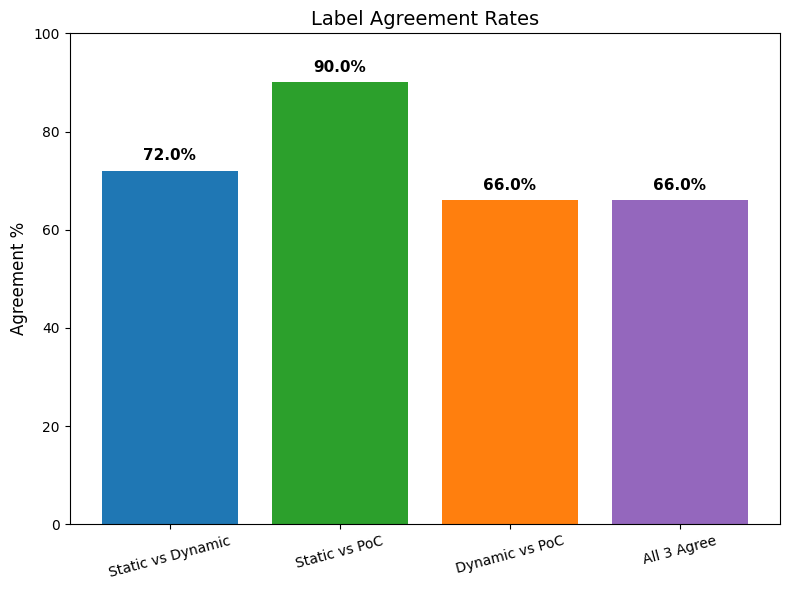

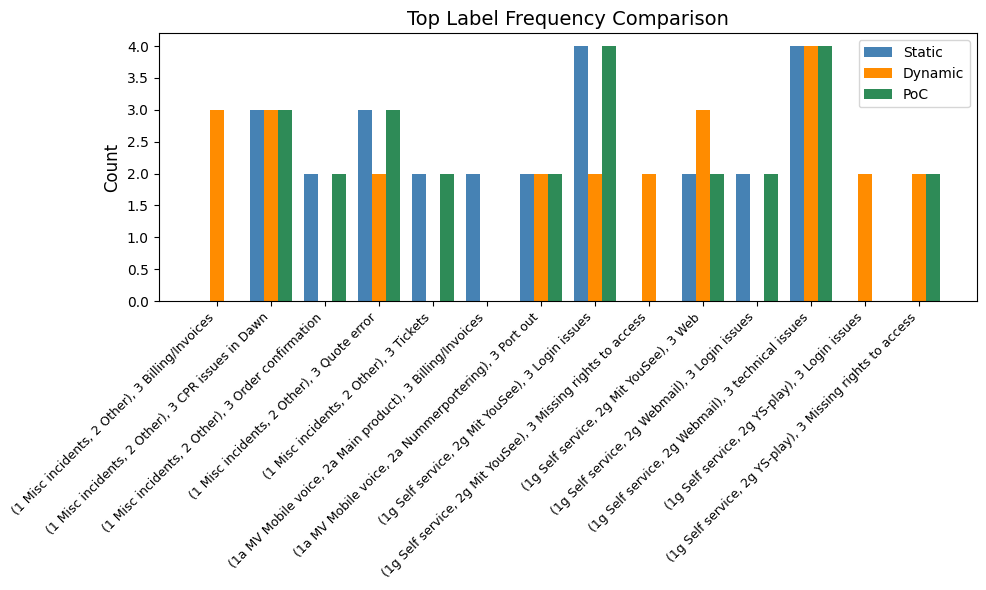

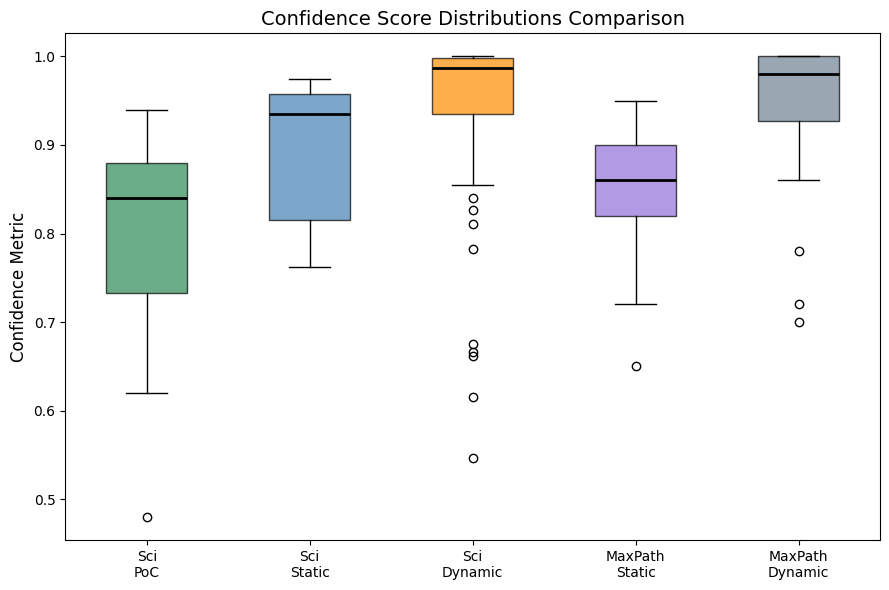

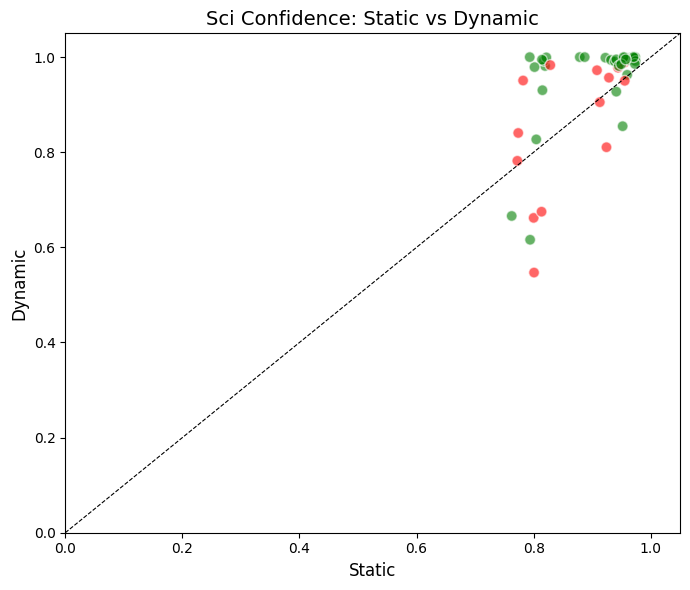

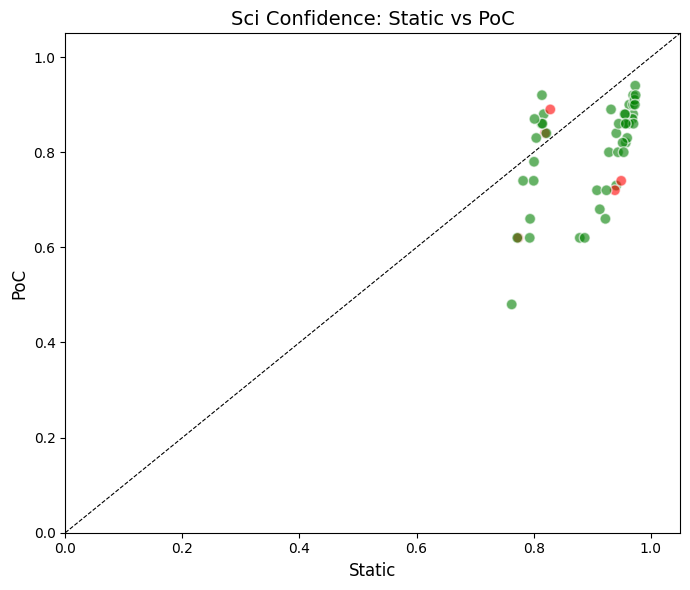

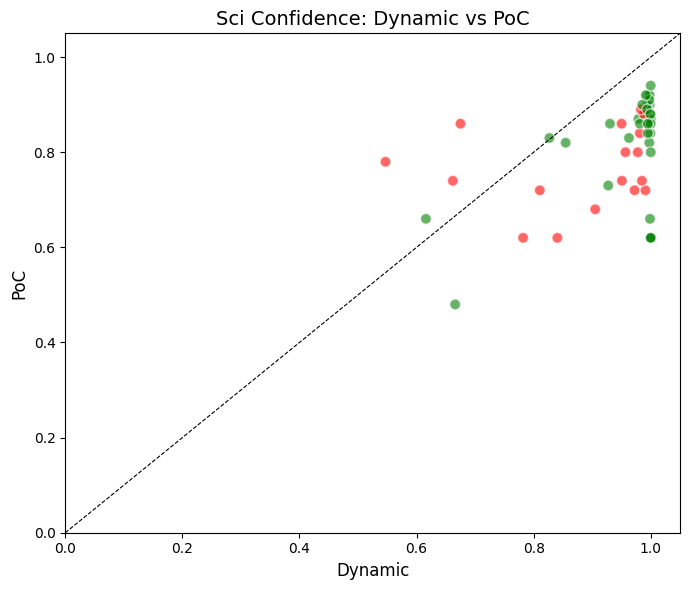

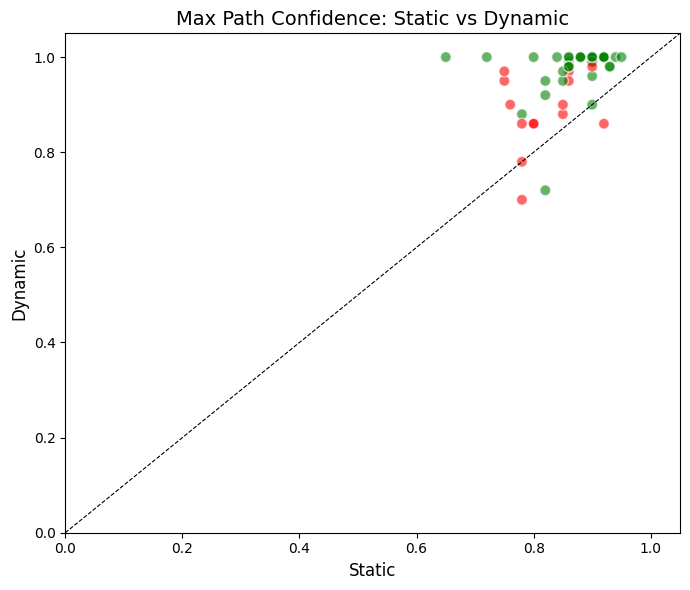

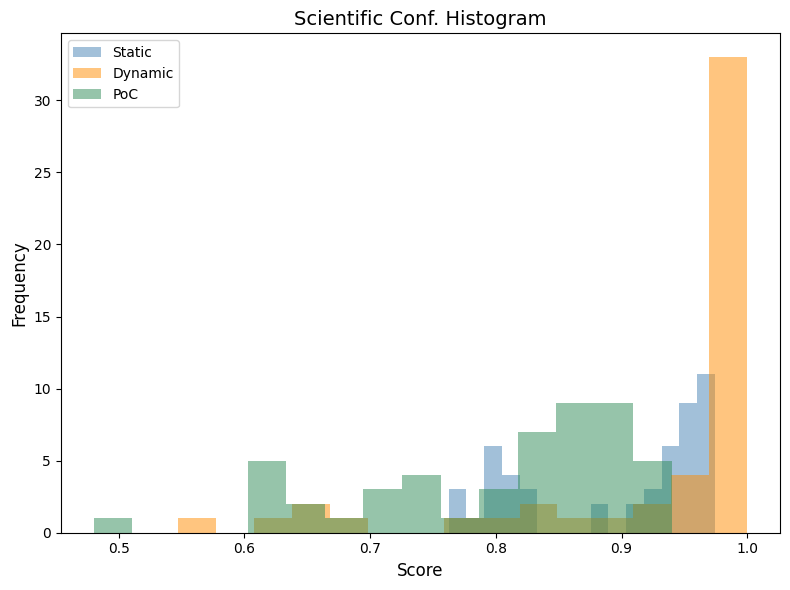

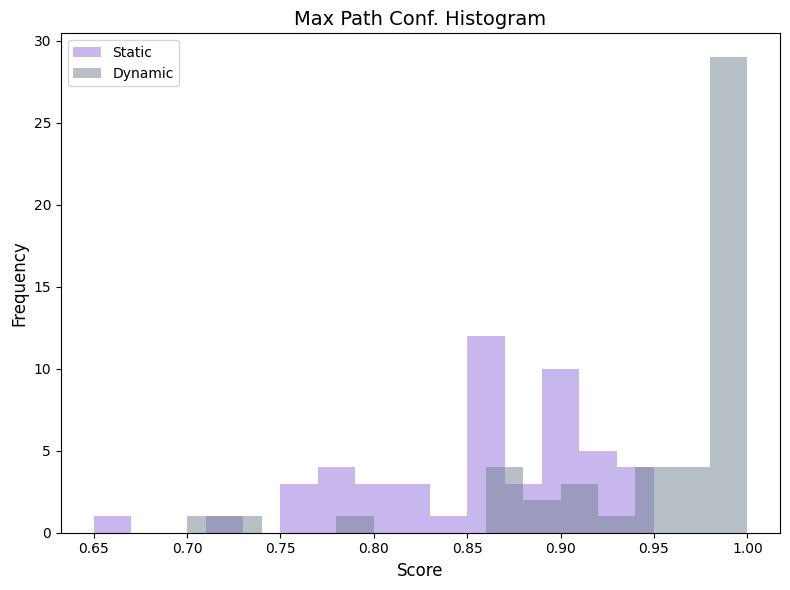

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Label Agreement Metrics
label_agree_sd = (merged['label_static'] == merged['label_dynamic'])
label_agree_sp = (merged['label_static'] == merged['label_poc'])
label_agree_dp = (merged['label_dynamic'] == merged['label_poc'])
label_agree_all3 = label_agree_sd & label_agree_sp

agree_summary = pd.Series({
    'Static vs Dynamic': label_agree_sd.mean() * 100,
    'Static vs PoC': label_agree_sp.mean() * 100,
    'Dynamic vs PoC': label_agree_dp.mean() * 100,
    'All 3 Agree': label_agree_all3.mean() * 100,
})

print('Label Agreement Summary (%)')
print(agree_summary.round(2))
print(f"\nAll-three label agreement: {label_agree_all3.sum()} / {len(merged)} ({agree_summary['All 3 Agree']:.1f}%)\n")

# --- Individual Visualizations ---

# 1.1) Agreement Bar Chart
plt.figure(figsize=(8, 6))
bar_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
bars = plt.bar(agree_summary.index, agree_summary.values, color=bar_colors)
plt.ylim(0, 100)
plt.ylabel('Agreement %', fontsize=12)
plt.title('Label Agreement Rates', fontsize=14)
plt.xticks(rotation=15)
for bar in bars:
    val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# 1.2) Top Label Distribution (All 3)
plt.figure(figsize=(10, 6))
top_n = 10
static_counts = merged['label_static'].value_counts().head(top_n)
dynamic_counts = merged['label_dynamic'].value_counts().head(top_n)
poc_counts = merged['label_poc'].value_counts().head(top_n)
all_labels = static_counts.index.union(dynamic_counts.index).union(poc_counts.index)

x = np.arange(len(all_labels))
w = 0.26
plt.bar(x - w, [static_counts.get(lbl, 0) for lbl in all_labels], w, label='Static', color='steelblue')
plt.bar(x, [dynamic_counts.get(lbl, 0) for lbl in all_labels], w, label='Dynamic', color='darkorange')
plt.bar(x + w, [poc_counts.get(lbl, 0) for lbl in all_labels], w, label='PoC', color='seagreen')
plt.xticks(x, all_labels, rotation=45, ha='right', fontsize=9)
plt.title('Top Label Frequency Comparison', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 1.3) Overall Confidence Boxplots
try:
    plt.figure(figsize=(9, 6))
    box_data = [
        merged['scientific_confidence_poc'].dropna(),
        merged['scientific_confidence_static'].dropna(),
        merged['scientific_confidence_dynamic'].dropna(),
        merged['max_path_confidence_static'].dropna(),
        merged['max_path_confidence_dynamic'].dropna()
    ]
    box_labels = ['Sci\nPoC', 'Sci\nStatic', 'Sci\nDynamic', 'MaxPath\nStatic', 'MaxPath\nDynamic']
    box_colors = ['seagreen', 'steelblue', 'darkorange', 'mediumpurple', 'slategray']

    ax = plt.gca()
    # Handle older matplotlib versions with `labels` fallback to fix the deprecation warning
    try:
        bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='black', linewidth=2), tick_labels=box_labels)
    except TypeError:
        bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='black', linewidth=2), labels=box_labels)
        
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    plt.title('Confidence Score Distributions Comparison', fontsize=14)
    plt.ylabel('Confidence Metric', fontsize=12)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")

# --- Scientific Confidence Scatter Plots ---
lims = [0, 1.05]

# 2.1) Sci S vs D
plt.figure(figsize=(7, 6))
c_sd = label_agree_sd.map({True: 'green', False: 'red'})
plt.scatter(merged['scientific_confidence_static'], merged['scientific_confidence_dynamic'], c=c_sd, alpha=0.6, edgecolors='white', s=60)
plt.plot(lims, lims, 'k--', lw=0.8)
plt.xlim(lims); plt.ylim(lims)
plt.title('Sci Confidence: Static vs Dynamic', fontsize=14)
plt.xlabel('Static', fontsize=12); plt.ylabel('Dynamic', fontsize=12)
plt.tight_layout()
plt.show()

# 2.2) Sci S vs P
plt.figure(figsize=(7, 6))
c_sp = label_agree_sp.map({True: 'green', False: 'red'})
plt.scatter(merged['scientific_confidence_static'], merged['scientific_confidence_poc'], c=c_sp, alpha=0.6, edgecolors='white', s=60)
plt.plot(lims, lims, 'k--', lw=0.8)
plt.xlim(lims); plt.ylim(lims)
plt.title('Sci Confidence: Static vs PoC', fontsize=14)
plt.xlabel('Static', fontsize=12); plt.ylabel('PoC', fontsize=12)
plt.tight_layout()
plt.show()

# 2.3) Sci D vs P
plt.figure(figsize=(7, 6))
c_dp = label_agree_dp.map({True: 'green', False: 'red'})
plt.scatter(merged['scientific_confidence_dynamic'], merged['scientific_confidence_poc'], c=c_dp, alpha=0.6, edgecolors='white', s=60)
plt.plot(lims, lims, 'k--', lw=0.8)
plt.xlim(lims); plt.ylim(lims)
plt.title('Sci Confidence: Dynamic vs PoC', fontsize=14)
plt.xlabel('Dynamic', fontsize=12); plt.ylabel('PoC', fontsize=12)
plt.tight_layout()
plt.show()

# --- Max Path Confidence Scatter & Histograms ---

# 3.1) Max Path Confidence Scatter: Static vs Dynamic
try:
    plt.figure(figsize=(7, 6))
    plt.scatter(merged['max_path_confidence_static'], merged['max_path_confidence_dynamic'], c=c_sd, alpha=0.6, edgecolors='white', s=60)
    plt.plot(lims, lims, 'k--', lw=0.8)
    plt.xlim(lims); plt.ylim(lims)
    plt.title('Max Path Confidence: Static vs Dynamic', fontsize=14)
    plt.xlabel('Static', fontsize=12); plt.ylabel('Dynamic', fontsize=12)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")

# 3.2) Histogram: Scientific Confidence Overview
plt.figure(figsize=(8, 6))
plt.hist(merged['scientific_confidence_static'].dropna(), bins=15, alpha=0.5, label='Static', color='steelblue')
plt.hist(merged['scientific_confidence_dynamic'].dropna(), bins=15, alpha=0.5, label='Dynamic', color='darkorange')
plt.hist(merged['scientific_confidence_poc'].dropna(), bins=15, alpha=0.5, label='PoC', color='seagreen')
plt.title('Scientific Conf. Histogram', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 3.3) Histogram: Max Path Confidence
try:
    plt.figure(figsize=(8, 6))
    plt.hist(merged['max_path_confidence_static'].dropna(), bins=15, alpha=0.5, label='Static', color='mediumpurple')
    plt.hist(merged['max_path_confidence_dynamic'].dropna(), bins=15, alpha=0.5, label='Dynamic', color='slategray')
    plt.title('Max Path Conf. Histogram', fontsize=14)
    plt.xlabel('Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")
